In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
df = pd.read_excel('advertising_sales_data.xlsx')

In [ ]:
print(df.isnull().sum())

Campaign     0
TV           0
Radio        2
Newspaper    0
Sales        0
dtype: int64


In [ ]:
df = df.dropna()


In [ ]:
X = df[['TV', 'Radio', 'Newspaper']].values
y = df['Sales'].values     #Selecting Salary Column(Second column)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=1)

In [ ]:
from sklearn.linear_model import LinearRegression
#Lets create an instance of our specific model
regressor=LinearRegression()
regressor.fit(X_train,y_train)


LinearRegression()

In [ ]:
y_pred=regressor.predict(X_test)

In [ ]:
coefficients = pd.Series(regressor.coef_, index=['TV', 'Radio', 'Newspaper'])
print("Coefficients:\n", coefficients)
print(f"The advertising medium with the highest impact on sales is {coefficients.idxmax()}")

Coefficients:
 TV           0.056423
Radio        0.108858
Newspaper   -0.004455
dtype: float64
The advertising medium with the highest impact on sales is Radio


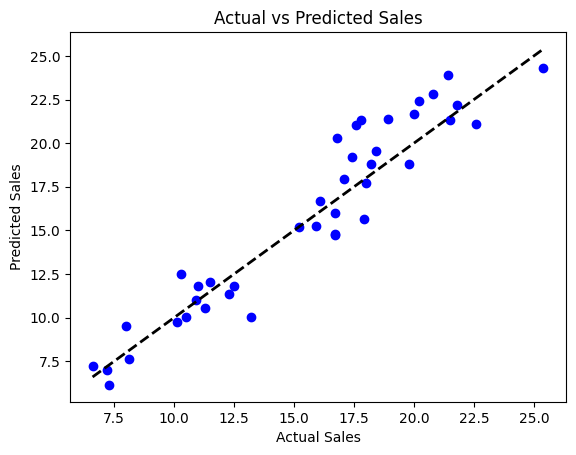

In [ ]:
# Plot actual vs predicted sales
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()


In [ ]:
# New advertising expenditures
new_data = pd.DataFrame({'TV': [200], 'Radio': [40], 'Newspaper': [50]})

# Predict sales for the new data
predicted_sales = regressor.predict(new_data)
print(f"The predicted sales for $200 on TV, $40 on Radio, and $50 on Newspaper is {predicted_sales[0]:.2f}")


The predicted sales for $200 on TV, $40 on Radio, and $50 on Newspaper is 19.93


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Normalize the dataset
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=0)

# Create and fit the normalized model
normalized_model = LinearRegression()
normalized_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_normalized = normalized_model.predict(X_test)
mse_normalized = mean_squared_error(y_test, y_pred_normalized)
print(f"The Mean Squared Error of the normalized model is {mse_normalized:.2f}")


The Mean Squared Error of the normalized model is 2.64


In [ ]:
# Prepare the data with only Radio and Newspaper
X_radio_newspaper = df[['Radio', 'Newspaper']]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_radio_newspaper, y, test_size=0.2, random_state=0)

# Create and fit the model
radio_newspaper_model = LinearRegression()
radio_newspaper_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_radio_newspaper = radio_newspaper_model.predict(X_test)
mse_radio_newspaper = mean_squared_error(y_test, y_pred_radio_newspaper)
print(f"The Mean Squared Error when using only Radio and Newspaper is {mse_radio_newspaper:.2f}")


The Mean Squared Error when using only Radio and Newspaper is 23.48


In [ ]:

from sklearn.metrics import mean_squared_error



# Prepare the data with only Radio and Newspaper
X_radio_newspaper = df[['Radio', 'Newspaper']].values
y = df['Sales'].values

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_radio_newspaper, y, test_size=0.2, random_state=1)

# Create and fit the model
regressor_radio_newspaper = LinearRegression()
regressor_radio_newspaper.fit(X_train, y_train)

# Predict the test set results
y_pred_radio_newspaper = regressor_radio_newspaper.predict(X_test)

# Calculate the Mean Squared Error
mse_radio_newspaper = mean_squared_error(y_test, y_pred_radio_newspaper)
print(f"Mean Squared Error when using only Radio and Newspaper: {mse_radio_newspaper:.2f}")

# Compare the coefficients to see the impact
coefficients_radio_newspaper = pd.Series(regressor_radio_newspaper.coef_, index=['Radio', 'Newspaper'])
print("Coefficients:\n", coefficients_radio_newspaper)
print(f"The advertising medium with the highest impact on sales (from Radio and Newspaper) is {coefficients_radio_newspaper.idxmax()}")


Mean Squared Error when using only Radio and Newspaper: 21.00
Coefficients:
 Radio        0.112768
Newspaper    0.020434
dtype: float64
The advertising medium with the highest impact on sales (from Radio and Newspaper) is Radio


In [ ]:

from sklearn.metrics import mean_squared_error

# Create and fit the model on non-normalized data
regressor_non_normalized = LinearRegression()
regressor_non_normalized.fit(X_train, y_train)
y_pred_non_normalized = regressor_non_normalized.predict(X_test)
mse_non_normalized = mean_squared_error(y_test, y_pred_non_normalized)
print(f"Mean Squared Error (Non-Normalized): {mse_non_normalized:.2f}")


Mean Squared Error (Non-Normalized): 2.68


In [ ]:
from sklearn.preprocessing import StandardScaler

# Normalize the dataset
scaler = StandardScaler()
X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

# Create and fit the model on normalized data
regressor_normalized = LinearRegression()
regressor_normalized.fit(X_train_normalized, y_train)
y_pred_normalized = regressor_normalized.predict(X_test_normalized)
mse_normalized = mean_squared_error(y_test, y_pred_normalized)
print(f"Mean Squared Error (Normalized): {mse_normalized:.2f}")


Mean Squared Error (Normalized): 2.68
